In [5]:
from pyotfs import System
sys=System(M=4,N=4,delta_f=1e6,cp_ln=2)
print(sys)

System(M=4, N=4, delta_f=1000000.0, cp_ln=2, constellation=Constellation(name='16-QAM', bits_per_symbol=4, lut={(0, 0): -3, (0, 1): -1, (1, 1): 1, (1, 0): 3}))


In [6]:
import numpy as np
np.random.seed(42)  # Set static seed for reproducible RTL bit-matching
total_bits_needed = sys.M * sys.N * 4
raw_bitstream = np.random.randint(0, 2, total_bits_needed).tolist()
cons=sys.modulate_bits(raw_bitstream)
print(cons)

[(-1-3j), (-1-3j), (-1-3j), (-3+3j), (1+3j), (3+1j), (1+1j), (1-3j), (1+3j), (3-3j), (-3+1j), (1+3j), (1-1j), (-1-1j), (3-3j), (-3-3j)]


In [7]:
# Explicit fixed-point quantization for RTL-aligned processing
Q_BITS = 3
Q_MIN = -(1 << (Q_BITS - 1))
Q_MAX = (1 << (Q_BITS - 1)) - 1

cons_np = np.array(cons, dtype=complex)
i_q = np.clip(np.rint(np.real(cons_np)), Q_MIN, Q_MAX).astype(int)
q_q = np.clip(np.rint(np.imag(cons_np)), Q_MIN, Q_MAX).astype(int)

cons_q = (i_q + 1j * q_q).tolist()
print("Quantized constellation stored in: cons_q")
print("Unique quantized points:", sorted(set((int(a), int(b)) for a, b in zip(i_q.flatten(), q_q.flatten()))))

Quantized constellation stored in: cons_q
Unique quantized points: [(-3, -3), (-3, 1), (-3, 3), (-1, -3), (-1, -1), (1, -3), (1, -1), (1, 1), (1, 3), (3, -3), (3, 1)]


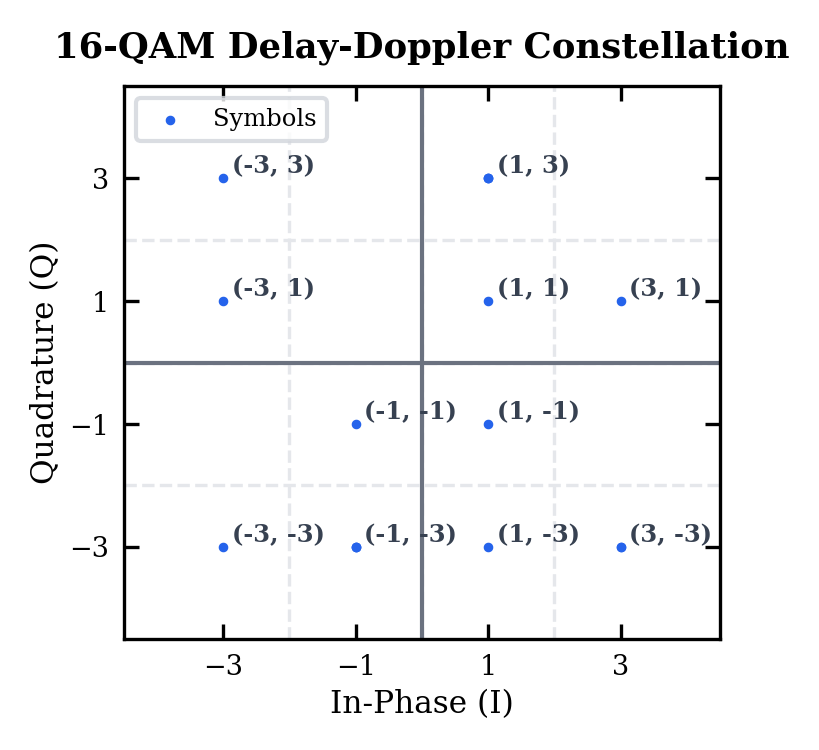

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# VISUALIZATION CHECKPOINT: COMPACT 16-QAM CONSTELLATION FOR REPORT
extracted_symbols = np.array(cons).flatten()
i_coords = [s.real for s in extracted_symbols]
q_coords = [s.imag for s in extracted_symbols]

plt.figure(figsize=(2.6, 2.6), dpi=300)
plt.rcParams["font.family"] = "serif"

# Custom gray dashed decision boundaries
for line in [-2, 0, 2]:
    plt.axvline(x=line, color="#e5e7eb", linestyle="--", linewidth=0.8, zorder=1)
    plt.axhline(y=line, color="#e5e7eb", linestyle="--", linewidth=0.8, zorder=1)

# Solid baseline coordinate axes
plt.axvline(x=0, color="#6b7280", linestyle="-", linewidth=1.0, zorder=2)
plt.axhline(y=0, color="#6b7280", linestyle="-", linewidth=1.0, zorder=2)

# Small markers for dense constellation display
plt.scatter(
    i_coords,
    q_coords,
    color="#2563eb",
    s=4,
    linewidths=0.3,
    marker="o",
    label="Symbols",
    zorder=3,
    )

# Compact coordinate labels
unique_points = sorted(set(zip(i_coords, q_coords)))
for i, q in unique_points:
    plt.text(
        i + 0.13,
        q + 0.08,
        f"({int(i)}, {int(q)})",
        color="#374151",
        fontsize=5.8,
        fontweight="bold",
        zorder=4,
    )

# Plot styling
ax = plt.gca()
ax.set_facecolor("white")
plt.gcf().patch.set_facecolor("white")
ax.tick_params(colors="black", labelsize=6.5, direction="in", top=True, right=True)
ax.grid(False)

# Axis boundaries and ticks
plt.xlim(-4.5, 4.5)
plt.ylim(-4.5, 4.5)
plt.xticks([-3, -1, 1, 3])
plt.yticks([-3, -1, 1, 3])

# Titles and labels
plt.title(
    "16-QAM Delay-Doppler Constellation",
    color="black",
    fontsize=8.5,
    pad=7,
    fontweight="bold",
    )
plt.xlabel("In-Phase (I)", color="black", fontsize=7.5, labelpad=2)
plt.ylabel("Quadrature (Q)", color="black", fontsize=7.5, labelpad=2)
plt.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#d1d5db",
    fontsize=5.8,
    )

plt.tight_layout()
plt.show()

In [9]:
import os
num_syms = sys.M * sys.N
os.makedirs("rtl/vectors", exist_ok=True)
with open("rtl/vectors/bitsstream.mem", "w") as f:
    for k in range(num_syms):
        b = raw_bitstream[4*k:4*k+4] # same 4-bit grouping as Python modulator
        f.write("".join(str(x) for x in b) + "\n")
f.close()

In [10]:
import os
import numpy as np
path = os.path.abspath(".") + "/"
# ---------------------------------------------------------------------
# ISFFT vector generation aligned to rtl/src/isfft_pingpong.sv fixed-point math
# ---------------------------------------------------------------------
IQ_WIDTH = 3
OUT_WIDTH = IQ_WIDTH + 4
MAX_FFT = 64
TW_W = 12
TW_FRAC = TW_W - 2

# Prefer explicitly quantized symbols when available
symbols_for_isfft = cons_q if "cons_q" in globals() else cons
D = np.array(symbols_for_isfft, dtype=complex).reshape(sys.M, sys.N)

def wrap_signed(v: int, width: int) -> int:
    mask = (1 << width) - 1
    u = int(v) & mask
    if u >= (1 << (width - 1)):
        u -= (1 << width)
    return u

def trunc_div_toward_zero(a: int, b: int) -> int:
    return int(a / b)

def int_sqrt_floor(v: int) -> int:
    x = 0
    while (x + 1) * (x + 1) <= v:
        x += 1
    return 1 if x == 0 else x

def to_tc_bin(v: int, width: int) -> str:
    u = v if v >= 0 else (1 << width) + v
    return format(u & ((1 << width) - 1), f"0{width}b")

# Input to ISFFT block equals quantized mapper outputs loaded by grid_loader (row-major)
in_i = [wrap_signed(int(np.rint(np.real(x))), IQ_WIDTH) for x in D.reshape(-1, order="C")]
in_q = [wrap_signed(int(np.rint(np.imag(x))), IQ_WIDTH) for x in D.reshape(-1, order="C")]

# Build twiddle LUT exactly like RTL initialization
ang = 2.0 * np.pi * np.arange(MAX_FFT) / MAX_FFT
tw_cos = np.rint(np.cos(ang) * (1 << TW_FRAC)).astype(int)
tw_sin = np.rint(np.sin(ang) * (1 << TW_FRAC)).astype(int)

M = sys.M
N = sys.N
TOTAL = M * N

# Row pass: y[k] = (1/sqrt(N)) * sum_n x[n] * exp(+j*2*pi*k*n/N)
row_i = [0] * TOTAL
row_q = [0] * TOTAL
sN = int_sqrt_floor(N)
for row_count in range(TOTAL):
    rr = row_count // N
    kk = row_count % N
    acc_r = 0
    acc_i = 0
    for nn in range(N):
        idx = rr * N + nn
        xr = in_i[idx]
        xi = in_q[idx]
        phase = ((kk * nn) * MAX_FFT) // N
        phase = phase % MAX_FFT
        wr = int(tw_cos[phase])
        wi = int(tw_sin[phase])
        pr = (xr * wr - xi * wi) >> TW_FRAC
        pi = (xr * wi + xi * wr) >> TW_FRAC
        acc_r += pr
        acc_i += pi
    row_i[row_count] = wrap_signed(trunc_div_toward_zero(acc_r, sN), OUT_WIDTH)
    row_q[row_count] = wrap_signed(trunc_div_toward_zero(acc_i, sN), OUT_WIDTH)

# Column pass: y[r] = (1/sqrt(M)) * sum_n x[n] * exp(-j*2*pi*r*n/M)
out_i = [0] * TOTAL
out_q = [0] * TOTAL
sM = int_sqrt_floor(M)
for col_count in range(TOTAL):
    rr = col_count // N
    cc = col_count % N
    acc_r = 0
    acc_i = 0
    for nn in range(M):
        idx = nn * N + cc
        xr = row_i[idx]
        xi = row_q[idx]
        phase = ((rr * nn) * MAX_FFT) // M
        phase = phase % MAX_FFT
        wr = int(tw_cos[phase])
        wi = -int(tw_sin[phase])
        pr = (xr * wr - xi * wi) >> TW_FRAC
        pi = (xr * wi + xi * wr) >> TW_FRAC
        acc_r += pr
        acc_i += pi
    out_i[col_count] = wrap_signed(trunc_div_toward_zero(acc_r, sM), OUT_WIDTH)
    out_q[col_count] = wrap_signed(trunc_div_toward_zero(acc_i, sM), OUT_WIDTH)

os.makedirs(path + "rtl/vectors", exist_ok=True)

with open(path + "rtl/vectors/ifft_in_i.mem", "w") as f:
    for v in in_i:
        f.write(to_tc_bin(v, IQ_WIDTH) + "\n")

with open(path + "rtl/vectors/ifft_in_q.mem", "w") as f:
    for v in in_q:
        f.write(to_tc_bin(v, IQ_WIDTH) + "\n")

with open(path + "rtl/vectors/ifft_exp_i.mem", "w") as f:
    for v in out_i:
        f.write(to_tc_bin(v, OUT_WIDTH) + "\n")

with open(path + "rtl/vectors/ifft_exp_q.mem", "w") as f:
    for v in out_q:
        f.write(to_tc_bin(v, OUT_WIDTH) + "\n")

print("Generated RTL-aligned ISFFT vectors:")
print(f"  {path}rtl/vectors/ifft_in_i.mem")
print(f"  {path}rtl/vectors/ifft_in_q.mem")
print(f"  {path}rtl/vectors/ifft_exp_i.mem")
print(f"  {path}rtl/vectors/ifft_exp_q.mem")
print(f"Total samples: {TOTAL}")

Generated RTL-aligned ISFFT vectors:
  /home/ashwin/Projects/CCU_INTERSHIP/rtl/vectors/ifft_in_i.mem
  /home/ashwin/Projects/CCU_INTERSHIP/rtl/vectors/ifft_in_q.mem
  /home/ashwin/Projects/CCU_INTERSHIP/rtl/vectors/ifft_exp_i.mem
  /home/ashwin/Projects/CCU_INTERSHIP/rtl/vectors/ifft_exp_q.mem
Total samples: 16


In [11]:
# Cyclic prefix insertion for each of the 4 OFDM symbols (N=4, CP=2) -> 24 samples total

cp_len = sys.cp_ln
M, N = sys.M, sys.N

i_mat = np.array(out_i, dtype=int).reshape(M, N)
q_mat = np.array(out_q, dtype=int).reshape(M, N)

i_cp = np.concatenate([i_mat[:, -cp_len:], i_mat], axis=1).reshape(-1).tolist()
q_cp = np.concatenate([q_mat[:, -cp_len:], q_mat], axis=1).reshape(-1).tolist()

os.makedirs(path + "rtl/vectors", exist_ok=True)

with open(path + "rtl/vectors/ifft_cp_in_i.mem", "w") as f:
    for v in i_cp:
        f.write(to_tc_bin(wrap_signed(int(v), OUT_WIDTH), OUT_WIDTH) + "\n")

with open(path + "rtl/vectors/ifft_cp_in_q.mem", "w") as f:
    for v in q_cp:
        f.write(to_tc_bin(wrap_signed(int(v), OUT_WIDTH), OUT_WIDTH) + "\n")

print("Generated CP-extended verification vectors:")
print(f"  {path}rtl/vectors/ifft_cp_in_i.mem")
print(f"  {path}rtl/vectors/ifft_cp_in_q.mem")
print(f"Total samples: {len(i_cp)}")

Generated CP-extended verification vectors:
  /home/ashwin/Projects/CCU_INTERSHIP/rtl/vectors/ifft_cp_in_i.mem
  /home/ashwin/Projects/CCU_INTERSHIP/rtl/vectors/ifft_cp_in_q.mem
Total samples: 24


## CP Verification Artifacts

This section emits a CSV for plotting the CP-extended transmitter output and writes a dedicated RTL testbench that uses `ifft_cp_in_i.mem` and `ifft_cp_in_q.mem` as the source of truth.